In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import glob
import numpy as np

from torch.autograd import Variable
from torch.utils.data.dataset import TensorDataset
from torch.utils.data import DataLoader

In [2]:
import glob
import numpy as np

from IPython.display import HTML
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.animation import FuncAnimation

In [3]:
DATA_PATH = "D:/GitHub/BaseballPitch/modules/motion_prediction/output.txt"

file = glob.glob(f"{DATA_PATH}")
file

['D:/GitHub/BaseballPitch/modules/motion_prediction/output.txt']

In [4]:
# Load keypoints from output.txt and display shape
keypoints = np.loadtxt(file[0])
print('Keypoints shape:', keypoints.shape)

Keypoints shape: (181, 56)


<class_index> <x_center> <y_center> <width> <height> <px1> <py1> [<pconf1>] <px2> <py2> [<pconf2>] ... 

In [5]:
def groups_of_three(arr):
    """
    Splits arr into non-overlapping groups of three elements.
    If the length is not a multiple of 3, the last group will be shorter.
    """
    return [arr[i:i+3] for i in range(0, len(arr), 3)]

In [6]:
groups_of_three(keypoints[1][5:])

[array([0.382573 , 0.456503 , 0.0571939]),
 array([3.79951e-01, 4.50765e-01, 6.78809e-05]),
 array([0.380866 , 0.449876 , 0.0628588]),
 array([0.369781  , 0.452147  , 0.00122458]),
 array([0.374628, 0.453689, 0.99003 ]),
 array([0.378208, 0.490815, 0.999115]),
 array([0.351212, 0.495859, 0.998687]),
 array([0.391583, 0.551081, 0.991214]),
 array([0.356988, 0.549888, 0.995944]),
 array([0.392896, 0.526   , 0.943886]),
 array([0.378408, 0.514813, 0.992335]),
 array([0.382996, 0.597103, 0.999657]),
 array([0.360728, 0.613186, 0.999531]),
 array([0.419018, 0.63074 , 0.999743]),
 array([0.369378, 0.700858, 0.999781]),
 array([0.443046, 0.721256, 0.999833]),
 array([0.365375, 0.805697, 0.999642])]

In [7]:
for i in range(17):
    kx, ky, kconf = groups_of_three(keypoints[i][5:])[i]  # Assuming the first 5 values are not keypoints
    print(kx, ky, kconf)

0.382414 0.456743 0.0406765
0.379951 0.450765 6.78809e-05
0.380529 0.449021 0.0996175
0.369968 0.451258 0.00102161
0.373539 0.454127 0.992607
0.379916 0.489372 0.999315
0.350805 0.499112 0.998749
0.39783 0.546441 0.994714
0.35943 0.554887 0.997952
0.396902 0.522442 0.924935
0.379447 0.514737 0.993418
0.387256 0.58138 0.9995
0.369861 0.609553 0.999543
0.407261 0.54372 0.995967
0.37848 0.69766 0.99844
0.404028 0.651449 0.998659
0.366253 0.806352 0.998734


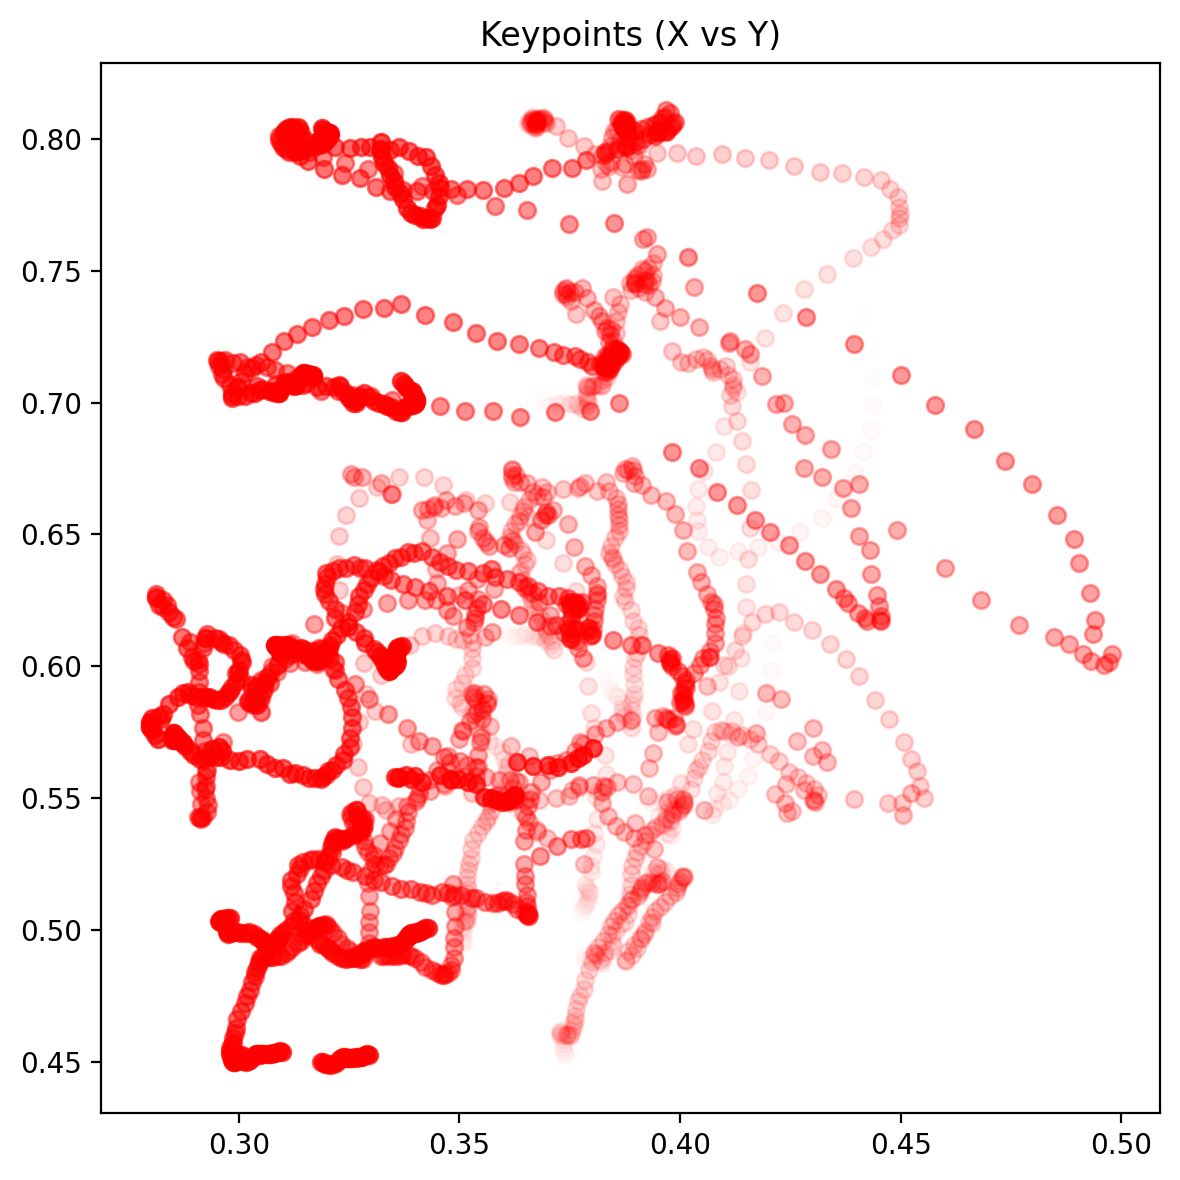

In [8]:
# XYZ coordinates subplot
fig, axs = plt.subplots(1, 1, figsize=(6, 6), facecolor='white', dpi=200)
alpha = 0

# XYZ coordinates for pos
for t in range(180):
    alpha += 1.0 / 249  # Gradually decrease the transparency
    for i in range(17):
        kx, ky, kconf = groups_of_three(keypoints[t][5:])[i]  # Assuming the first 5 values are not keypoints

        if kconf > 0.5:
            axs.plot(kx, ky, 'ro', alpha = alpha)  # Plot keypoints as red dots
            axs.set_title('Keypoints (X vs Y)')

plt.tight_layout()
plt.show()

In [9]:
def plot_line(axs, pt1, pt2, **kwargs):
    """
    Plots a line between two points on the given matplotlib axis.
    pt1, pt2: (x, y) tuples or arrays
    axs: matplotlib axis object
    kwargs: additional arguments for axs.plot (e.g., color, linewidth)
    """
    x_values = [pt1[0], pt2[0]]
    y_values = [pt1[1], pt2[1]]
    axs.plot(x_values, y_values, **kwargs)

In [10]:
coco_connections = [
    # Head
    (0, 1), (0, 2), (1, 3), (2, 4),
    # Torso
    (5, 6), (5, 11), (6, 12), (11, 12),
    # Left Arm
    (5, 7), (7, 9),
    # Right Arm
    (6, 8), (8, 10),
    # Left Leg
    (11, 13), (13, 15),
    # Right Leg
    (12, 14), (14, 16)
]

In [11]:
edges = [([conn[0]], [conn[1]]) for conn in coco_connections]
print(edges[0])

([0], [1])


In [12]:
nodes = np.zeros([180,17,2])
edges = np.zeros([180,16,2,2])  # 12 edges, each with 2 points (start and end), each point has (x, y)

# XYZ coordinates for pos
for t in range(180):
    for i in range(17):
        kx, ky, kconf = groups_of_three(keypoints[t][5:])[i]  # Assuming the first 5 values are not keypoints
        nodes[t][i] = ([kx, ky])
    edges[t] = [(nodes[t][conn[0]], nodes[t][conn[1]]) for conn in coco_connections]
    
print(edges[0][0])

[[0.382414 0.456743]
 [0.37966  0.450746]]


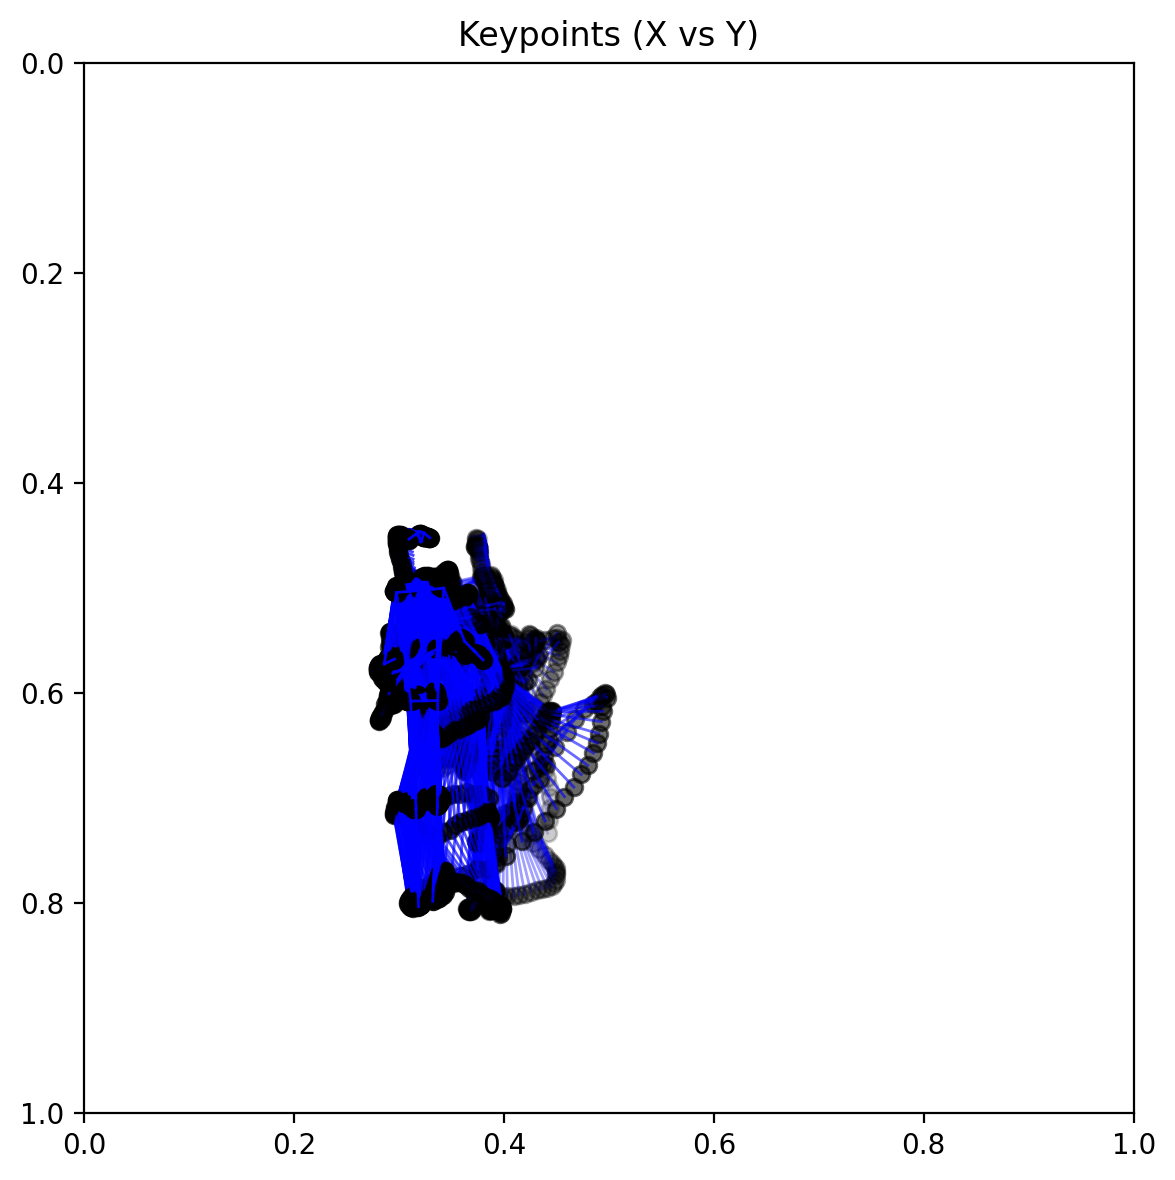

In [13]:
# XYZ coordinates subplot
fig, axs = plt.subplots(1, 1, figsize=(6, 6), facecolor='white', dpi=200)
alpha = 0.2
nodes = np.zeros([180,17,2])
edges = np.zeros([180,16,2,2])  # 12 edges, each with 2 points (start and end), each point has (x, y)

# XYZ coordinates for pos
for t in range(180):
    alpha += 1.0 / 249  # Gradually decrease the transparency
    for i in range(17):
        kx, ky, kconf = groups_of_three(keypoints[t][5:])[i]  # Assuming the first 5 values are not keypoints
        nodes[t][i] = ([kx, ky])
        if kconf > 0.5:
            axs.plot(kx, ky, 'ko', alpha = alpha)  # Plot keypoints as red dots
    edges[t] = [(nodes[t][conn[0]], nodes[t][conn[1]]) for conn in coco_connections]
    for i in range(16):
        plot_line(axs, edges[t][i][0], edges[t][i][1], color='blue', linewidth=1, alpha=alpha)  # Plot edges as blue lines

axs.invert_yaxis()            # Flips the Y-axis so the head is at the top
axs.set_xlim(0, 1)            # Locks X-axis to normalized image bounds
axs.set_ylim(1, 0)            # Locks Y-axis to normalized bounds (1 at bottom, 0 at top)
axs.set_aspect('equal')       # Prevents the skeleton from stretching horizontally/vertically
axs.set_title('Keypoints (X vs Y)')
plt.tight_layout()
plt.show()

In [14]:
from ipywidgets import interact, IntSlider

def plot_pose_at_timestep(timestep):
    fig, axs = plt.subplots(1, 1, figsize=(3, 3), facecolor='white', dpi=200)
    alpha = 1.0
    nodes = np.zeros([17,2])
    for i in range(17):
        kx, ky, kconf = groups_of_three(keypoints[timestep][5:])[i]
        nodes[i] = ([kx, ky])
        if kconf > 0.5:
            axs.plot(kx, ky, 'ko', alpha=alpha)
    for conn in coco_connections:
        plot_line(axs, nodes[conn[0]], nodes[conn[1]], color='blue', linewidth=1, alpha=alpha)
    
    axs.invert_yaxis()            # Flips the Y-axis so the head is at the top
    axs.set_xlim(0, 1)            # Locks X-axis to normalized image bounds
    axs.set_ylim(1, 0)            # Locks Y-axis to normalized bounds (1 at bottom, 0 at top)
    axs.set_aspect('equal')       # Prevents the skeleton from stretching horizontally/vertically
    
    axs.set_title(f'Keypoints (X vs Y) - Timestep {timestep}')
    plt.tight_layout()
    plt.show()

interact(plot_pose_at_timestep, timestep=IntSlider(min=0, max=keypoints.shape[0]-1, step=1, value=0))

interactive(children=(IntSlider(value=0, description='timestep', max=180), Output()), _dom_classes=('widget-in…

<function __main__.plot_pose_at_timestep(timestep)>

In [15]:
from ipywidgets import Play, IntSlider, jslink, VBox

def plot_pose_at_timestep(timestep):
    fig, axs = plt.subplots(1, 1, figsize=(3, 3), facecolor='white', dpi=200)
    alpha = 1.0
    nodes = np.zeros([17,2])
    for i in range(17):
        kx, ky, kconf = groups_of_three(keypoints[timestep][5:])[i]
        nodes[i] = ([kx, ky])
        if kconf > 0.5:
            axs.plot(kx, ky, 'ko', alpha=alpha)
    for conn in coco_connections:
        plot_line(axs, nodes[conn[0]], nodes[conn[1]], color='blue', linewidth=1, alpha=alpha)
    axs.invert_yaxis()            # Flips the Y-axis so the head is at the top
    axs.set_xlim(0, 1)            # Locks X-axis to normalized image bounds
    axs.set_ylim(1, 0)            # Locks Y-axis to normalized bounds (1 at bottom, 0 at top)
    axs.set_aspect('equal')       # Prevents the skeleton from stretching horizontally/vertically
    axs.set_title(f'Keypoints (X vs Y) - Timestep {timestep}')
    plt.tight_layout()
    plt.show()

play = Play(value=0, min=0, max=keypoints.shape[0]-1, step=1, interval=50, description="Press play", repeat=True)
slider = IntSlider(min=0, max=keypoints.shape[0]-1, step=1, value=0)
jslink((play, 'value'), (slider, 'value'))

from ipywidgets import interactive_output
out = interactive_output(plot_pose_at_timestep, {'timestep': slider})

VBox([play, slider, out])